<a href="https://colab.research.google.com/github/penguin-trooper/MachineLearning/blob/main/FiveFingers_KTM_machine_learningipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import Libraries
# This cell imports all necessary libraries for the project.

import pandas as pd # Imports Pandas for data manipulation and analysis, especially with DataFrames.
import numpy as np # Imports NumPy for numerical operations, supporting multi-dimensional arrays and mathematical functions.
from sklearn.model_selection import train_test_split, GridSearchCV # From scikit-learn's model selection module:
# train_test_split: Used to divide datasets into training and testing subsets.
# GridSearchCV: Used for hyperparameter tuning by exhaustively searching over specified parameter values.

from sklearn.ensemble import RandomForestClassifier # Imports the Random Forest classification algorithm, an ensemble method.
from sklearn.linear_model import LogisticRegression # Imports Logistic Regression, a linear model used for binary classification.
from sklearn.tree import DecisionTreeClassifier # Imports the Decision Tree classification algorithm.
from sklearn.neighbors import KNeighborsClassifier # Imports K-Nearest Neighbors (KNN), a non-parametric classification algorithm.
from sklearn.svm import SVC # Imports Support Vector Classifier (SVC), a powerful classification algorithm.

from sklearn.preprocessing import StandardScaler # Imports StandardScaler for standardizing features (mean=0, variance=1).
from sklearn.decomposition import PCA # Imports Principal Component Analysis (PCA) for dimensionality reduction.

from sklearn.metrics import classification_report, accuracy_score # From scikit-learn's metrics module:
# classification_report: Generates a text report showing main classification metrics (precision, recall, F1-score).
# accuracy_score: Calculates the proportion of correctly classified instances.

import matplotlib.pyplot as plt # Imports Matplotlib's pyplot module for creating static, animated, and interactive visualizations.
import seaborn as sns # Imports Seaborn, a data visualization library based on Matplotlib, for attractive statistical graphics.



!pip install auto-sklearn

print("All necessary libraries imported successfully!")

  Using cached auto-sklearn-0.15.0.tar.gz (6.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scikit-learn-0.24.2.tar.gz (7.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
All necessary libraries imported successfully!


In [ ]:
# Cell 2: Data Loading and Initial Exploration
# URL for the Komuter ridership data in Parquet format
URL_DATA = 'https://storage.data.gov.my/transportation/ktmb/komuter_2025.parquet'

# Load the dataset
print("--- Loading data from Parquet URL ---")
df = pd.read_parquet(URL_DATA)

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

print("\n--- First 5 rows of the dataset ---")
print(df.head())
print("\n--- Dataset Information ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())

--- Loading data from Parquet URL ---

--- First 5 rows of the dataset ---
        date   time          origin       destination  ridership
0 2025-01-01  00:00  Abdullah Hukum             Klang          1
1 2025-01-01  00:00  Abdullah Hukum       Telok Pulai          1
2 2025-01-01  00:00           Bangi        Batu Caves          1
3 2025-01-01  00:00     Bank Negara      Sungai Gadut          1
4 2025-01-01  00:00       Batu Tiga  Kampung Raja Uda          1

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946455 entries, 0 to 946454
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         946455 non-null  datetime64[us]
 1   time         946455 non-null  object        
 2   origin       946455 non-null  object        
 3   destination  946455 non-null  object        
 4   ridership    946455 non-null  int64         
dtypes: datetime64[us](1), int64(1), object(3)

In [ ]:
# Cell 3: Filter Data for a Specific Origin-Destination Pair
origin_station = 'Abdullah Hukum'
destination_station = 'Klang'

df_filtered = df[(df['origin'] == origin_station) & (df['destination'] == destination_station)].copy()
print(f"\n--- Filtered data for {origin_station} to {destination_station} ---")
print(df_filtered.head())
print(f"Number of records for this route: {len(df_filtered)}")


--- Filtered data for Abdullah Hukum to Klang ---
           date   time          origin destination  ridership
0    2025-01-01  00:00  Abdullah Hukum       Klang          1
4429 2025-01-01  17:00  Abdullah Hukum       Klang          3
4876 2025-01-01  18:00  Abdullah Hukum       Klang          5
5356 2025-01-01  19:00  Abdullah Hukum       Klang          1
5773 2025-01-01  20:00  Abdullah Hukum       Klang          4
Number of records for this route: 862


In [ ]:
# Cell 4: Feature Engineering - Time-based Features

df_filtered['date'] = pd.to_datetime(df_filtered['date'])
df_filtered['hour'] = df_filtered['time'].apply(lambda x: int(x.split(':')[0])) # Extract hour from time string
df_filtered['day_of_week'] = df_filtered['date'].dt.dayofweek # Monday=0, Sunday=6
df_filtered['is_weekend'] = df_filtered['day_of_week'].apply(lambda x: 1 if x >= 5 else 0) # 1 for Sat/Sun, 0 for Weekday
df_filtered['month'] = df_filtered['date'].dt.month # Month number (1-12)

print("\n--- Filtered data with new time-based features ---")
print(df_filtered[['date', 'time', 'hour', 'day_of_week', 'is_weekend', 'month', 'ridership']].head())


--- Filtered data with new time-based features ---
           date   time  hour  day_of_week  is_weekend  month  ridership
0    2025-01-01  00:00     0            2           0      1          1
4429 2025-01-01  17:00    17            2           0      1          3
4876 2025-01-01  18:00    18            2           0      1          5
5356 2025-01-01  19:00    19            2           0      1          1
5773 2025-01-01  20:00    20            2           0      1          4


In [ ]:
# Cell 5: Group Data to Create Samples for Peak Hour Prediction and Define Target
# Group by hour, day_of_week, is_weekend, and month to get ridership for each unique combination
hourly_features = df_filtered.groupby(['hour', 'day_of_week', 'is_weekend', 'month'])['ridership'].sum().reset_index()


top_peak_hours = df_filtered.groupby('hour')['ridership'].sum().nlargest(3).index.tolist()

# Add the target variable: 'is_peak_hour'
hourly_features['is_peak_hour'] = hourly_features['hour'].apply(lambda x: 1 if x in top_peak_hours else 0)

print("\n--- Hourly Features DataFrame for Modeling ---")
print(hourly_features.head())
print(f"\nTop 3 Global Peak Hours: {top_peak_hours}")
print(f"Count of Peak Hour labels (1): {hourly_features['is_peak_hour'].sum()}")
print(f"Count of Non-Peak Hour labels (0): {len(hourly_features) - hourly_features['is_peak_hour'].sum()}")



--- Hourly Features DataFrame for Modeling ---
   hour  day_of_week  is_weekend  month  ridership  is_peak_hour
0     0            2           0      1          1             0
1     0            3           0      1          2             0
2     0            6           1      1          2             0
3     1            3           0      1          1             0
4     1            4           0      1          2             0

Top 3 Global Peak Hours: [19, 18, 20]
Count of Peak Hour labels (1): 119
Count of Non-Peak Hour labels (0): 254


In [ ]:
# Cell 6: Feature Engineering - Cyclical Encoding and Feature Selection for PCA
# Create cyclical features for 'hour', 'day_of_week', and 'month'
X = hourly_features[['hour', 'day_of_week', 'is_weekend', 'month']].copy()

X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)
X['day_sin'] = np.sin(2 * np.pi * X['day_of_week'] / 7)
X['day_cos'] = np.cos(2 * np.pi * X['day_of_week'] / 7)

# Encode 'month' (1=Jan, 12=Dec)
X['month_sin'] = np.sin(2 * np.pi * (X['month'] - 1) / 12)
X['month_cos'] = np.cos(2 * np.pi * (X['month'] - 1) / 12)

# Drop original time columns as their cyclical representations are now present
X = X.drop(['hour', 'day_of_week', 'month'], axis=1)

y = hourly_features['is_peak_hour'] # Our target variable

print("\n--- Features (X) after Cyclical Encoding ---")
print(X.head())
print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")


--- Features (X) after Cyclical Encoding ---
   is_weekend  hour_sin  hour_cos  day_sin  day_cos  month_sin  month_cos
0           0      0.00      1.00     0.97    -0.22       0.00       1.00
1           0      0.00      1.00     0.43    -0.90       0.00       1.00
2           1      0.00      1.00    -0.78     0.62       0.00       1.00
3           0      0.26      0.97     0.43    -0.90       0.00       1.00
4           0      0.26      0.97    -0.43    -0.90       0.00       1.00

Shape of features (X): (373, 7)
Shape of target (y): (373,)


In [ ]:
# Cell 7: Data Splitting, Standardization, and PCA
# Split into training and testing sets FIRST to prevent data leakage during scaling/PCA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Added stratify=y to ensure similar proportion of peak/non-peak hours in train/test sets

# Scale features using training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use the same scaler for test data

# Apply PCA for dimensionality reduction
pca = PCA(n_components=4, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled) # Transform test data using PCA fitted on training data

print(f"\nTraining features shape after PCA: {X_train_pca.shape}")
print(f"Testing features shape after PCA: {X_test_pca.shape}")
print(f"Explained variance ratio by principal components: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.4f}")


Training features shape after PCA: (298, 4)
Testing features shape after PCA: (75, 4)
Explained variance ratio by principal components: [0.27394447 0.24324894 0.15462376 0.14272641]
Cumulative explained variance: 0.8145


In [ ]:
# Cell 8: Hyperparameter Tuning using GridSearchCV for 5 Models
print("\n--- Starting Hyperparameter Tuning with GridSearchCV ---")
best_models = {}

# 1. Tune Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['lbfgs', 'liblinear'] # Optimization algorithm. lbfgs is good for multi-class, liblinear for small datasets
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42), # Increased max_iter for convergence
    param_grid=param_grid_lr, cv=5, scoring='accuracy', verbose=1, n_jobs=-1
)
grid_lr.fit(X_train_pca, y_train)
best_models['Tuned Logistic Regression'] = grid_lr.best_estimator_
print(f"Best params for Logistic Regression: {grid_lr.best_params_}")

# 2. Tune Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20], # Tree depth
    'min_samples_split': [2, 5, 10], # Min samples required to split an internal node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt, cv=5, scoring='accuracy', verbose=1, n_jobs=-1
)
grid_dt.fit(X_train_pca, y_train)
best_models['Tuned Decision Tree'] = grid_dt.best_estimator_
print(f"Best params for Decision Tree: {grid_dt.best_params_}")

# 3. Tune Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200], # Number of trees in the forest
    'max_depth': [None, 10, 15, 20], # Maximum depth of the tree
    'min_samples_split': [2, 5] # Minimum number of samples required to split an internal node
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf, cv=5, scoring='accuracy', verbose=1, n_jobs=-1
)
grid_rf.fit(X_train_pca, y_train)
best_models['Tuned Random Forest'] = grid_rf.best_estimator_
print(f"Best params for Random Forest: {grid_rf.best_params_}")

# 4. Tune K-Nearest Neighbors (KNN)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9], # Number of neighbors to use
    'weights': ['uniform', 'distance'], # Weight function used in prediction
    'metric': ['euclidean', 'manhattan'] # Distance metric to use
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid_knn, cv=5, scoring='accuracy', verbose=1, n_jobs=-1
)
grid_knn.fit(X_train_pca, y_train)
best_models['Tuned KNN'] = grid_knn.best_estimator_
print(f"Best params for KNN: {grid_knn.best_params_}")

# 5. Tune SVM (RBF Kernel)
param_grid_svm = {
    'C': [0.1, 1, 10], # Regularization parameter
    'gamma': ['scale', 'auto', 0.1, 1], # Kernel coefficient
    'kernel': ['rbf'] # Kernel type. Fixed to rbf as per problem description.
}
grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid=param_grid_svm, cv=3, scoring='accuracy', verbose=1, n_jobs=-1
) # Reduced CV to 3-fold for SVM for faster execution
grid_svm.fit(X_train_pca, y_train)
best_models['Tuned SVM (RBF)'] = grid_svm.best_estimator_
print(f"Best params for SVM (RBF): {grid_svm.best_params_}")

print("\n--- Hyperparameter Tuning Complete ---")


--- Starting Hyperparameter Tuning with GridSearchCV ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params for Logistic Regression: {'C': 0.01, 'solver': 'liblinear'}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params for Decision Tree: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 2}
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for KNN: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params for SVM (RBF): {'C': 10, 'gamma': 1, 'kernel': 'rbf'}

--- Hyperparameter Tuning Complete ---


In [ ]:
# Cell 9: Evaluate Tuned Models
print("\n--- Evaluation of Tuned Models ---")
evaluation_results = {}

for name, model in best_models.items():
    # Predict using the PCA-transformed test data
    y_pred = model.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True) # Output as dict for easy access

    evaluation_results[name] = {
        'Accuracy': accuracy,
        'Precision (1)': report['1']['precision'],
        'Recall (1)': report['1']['recall'],
        'F1-Score (1)': report['weighted avg']['f1-score'],
        'Classification Report': classification_report(y_test, y_pred, zero_division=0)
    }

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(evaluation_results[name]['Classification Report'])


--- Evaluation of Tuned Models ---

--- Tuned Logistic Regression ---
Accuracy: 0.6400
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72        51
           1       0.45      0.54      0.49        24

    accuracy                           0.64        75
   macro avg       0.60      0.61      0.61        75
weighted avg       0.66      0.64      0.65        75


--- Tuned Decision Tree ---
Accuracy: 0.6800
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        51
           1       0.50      0.54      0.52        24

    accuracy                           0.68        75
   macro avg       0.64      0.64      0.64        75
weighted avg       0.69      0.68      0.68        75


--- Tuned Random Forest ---
Accuracy: 0.6933
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.7

In [ ]:
# Cell 10: Final Comparison of Tuned Custom Models
print("\n" + "="*50)
print("Final Comparison: Tuned Custom Models")
print("="*50)

# Find the best custom model based on accuracy
best_custom_model_name = ""
best_custom_model_accuracy = -1.0
for name, metrics in evaluation_results.items():
    if metrics['Accuracy'] > best_custom_model_accuracy:
        best_custom_model_accuracy = metrics['Accuracy']
        best_custom_model_name = name

print(f"Best Tuned Custom Model: {best_custom_model_name}")
print(f"- Accuracy: {best_custom_model_accuracy:.4f}")

# You can also print accuracy for all tuned models for a full comparison
print("\n--- Accuracy of all Tuned Models ---")
for name, metrics in evaluation_results.items():
    print(f"- {name}: {metrics['Accuracy']:.4f}")

print("\nConclusion: The best performing tuned model is identified above.")


Final Comparison: Tuned Custom Models
Best Tuned Custom Model: Tuned KNN
- Accuracy: 0.7333

--- Accuracy of all Tuned Models ---
- Tuned Logistic Regression: 0.6400
- Tuned Decision Tree: 0.6800
- Tuned Random Forest: 0.6933
- Tuned KNN: 0.7333
- Tuned SVM (RBF): 0.7333

Conclusion: The best performing tuned model is identified above.



--- Visualization of Overall Hourly Ridership ---
The value of peak_hour (global max ridership hour): 19


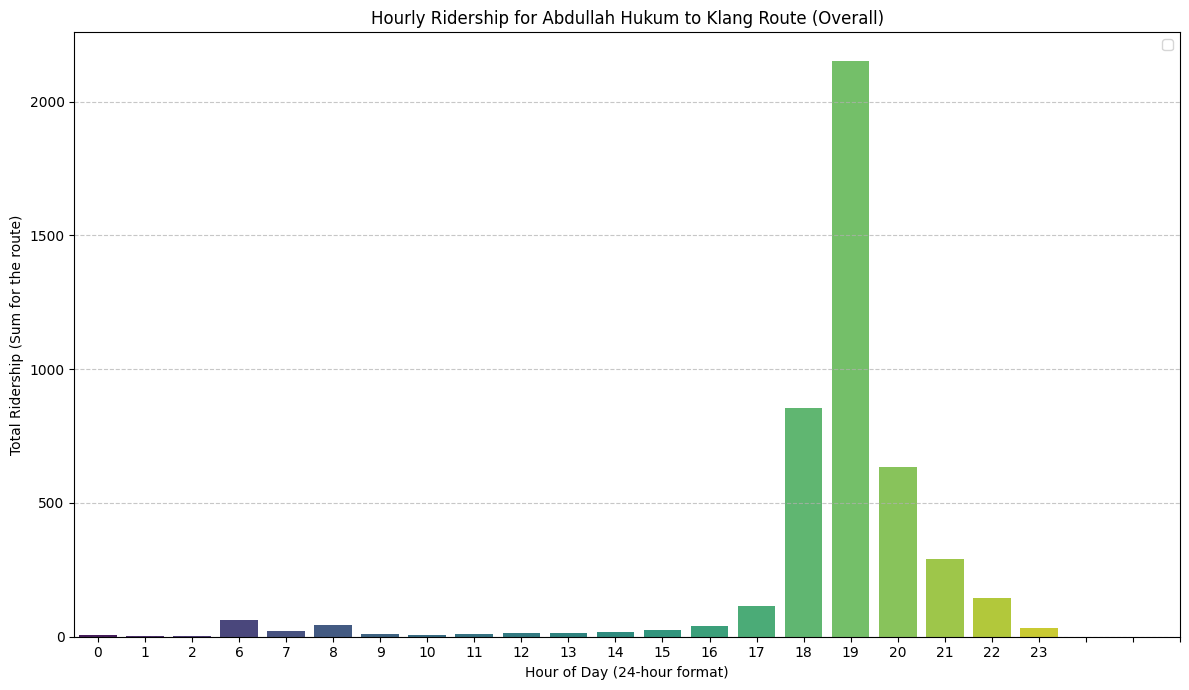

In [ ]:
# Cell 11: Visualization of Overall Hourly Ridership and Identified Peak Hour
print(f"\n--- Visualization of Overall Hourly Ridership ---")

# Re-calculate hourly_ridership using df_filtered to ensure it's specific to the chosen route
# This calculation is for plotting purposes only, showing the overall ridership pattern by hour.
hourly_ridership_plot = df_filtered.groupby('hour')['ridership'].sum().reset_index()

# Debugging print to confirm the peak_hour value before plotting
peak_hour = top_peak_hours[0]
print(f"The value of peak_hour (global max ridership hour): {peak_hour}")

plt.figure(figsize=(12, 7)) # Increased figure size for better readability
sns.barplot(x='hour', y='ridership', data=hourly_ridership_plot, palette='viridis') # Using 'viridis' palette
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Total Ridership (Sum for the route)')
plt.title(f'Hourly Ridership for {origin_station} to {destination_station} Route (Overall)')
plt.xticks(range(24)) # Ensure all 24 hours are shown on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for readability
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


--- Generating Bar Chart: F1-Score for Class 1 (Peak Hour) - Tuned Models Only ---


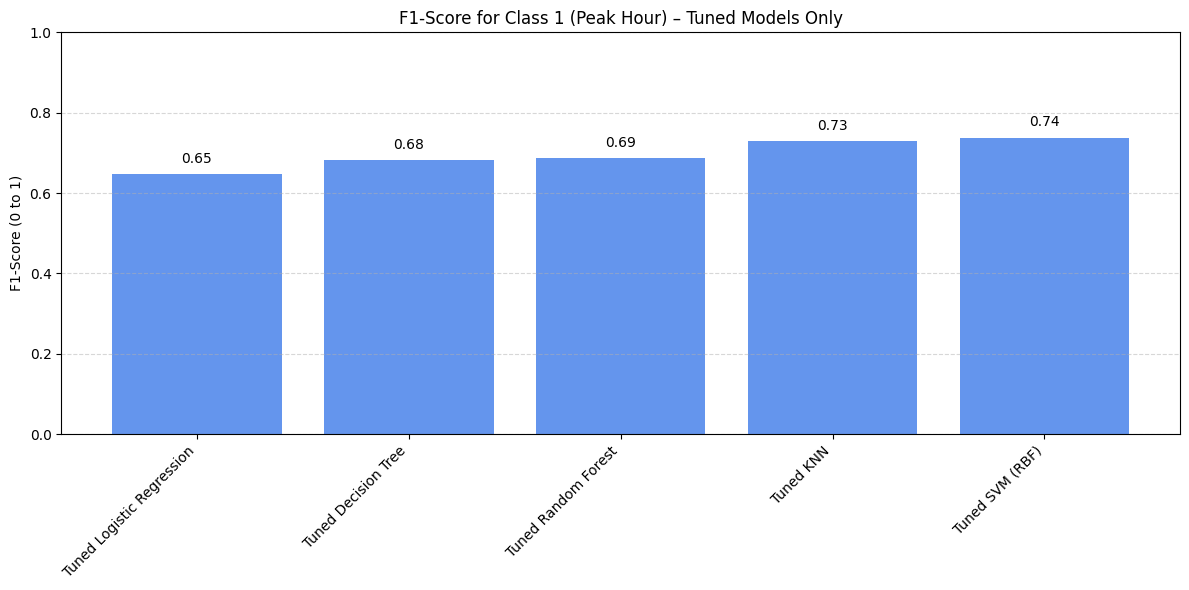

In [ ]:
# Cell 12: Visual Comparison of F1-Score (Class 1 - Peak Hour) for Tuned Models Only

print("\n--- Generating Bar Chart: F1-Score for Class 1 (Peak Hour) - Tuned Models Only ---")

# Extract model names and corresponding F1-scores (for class 1 only)
model_names = list(evaluation_results.keys())
f1_scores_class1 = [evaluation_results[name]['F1-Score (1)'] for name in model_names]

# Plot bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, f1_scores_class1, color='cornflowerblue')
plt.title("F1-Score for Class 1 (Peak Hour) – Tuned Models Only")
plt.ylabel("F1-Score (0 to 1)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
from auto_sklearn2 import AutoSklearnRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler

print("jadi")

# Step 3: Initialize AutoML regressor
automl = AutoSklearnRegressor()

# Step 4: Train on training data
automl.fit(X_train_pca, y_train)

# Step 5: Predict on test data
y_pred = automl.predict(X_test_pca)

# Set a threshold, e.g., 0.5
y_pred_class = (y_pred >= 0.5).astype(int)

# Convert continuous predictions to binary labels
y_pred_binary = (y_pred >= 0.5).astype(int)

automl_f1_score_class_1 = f1_score(y_test, y_pred_binary)
automl_accuracy = accuracy_score(y_test, y_pred_binary)
automl_classification_report = classification_report(y_test, y_pred_binary)

# Step 6: Evaluate the model
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("Accuracy:", automl_accuracy)
print("F1 Score:", automl_f1_score_class_1)

# Show top models
# print("\nTop Models:\n", automl.leaderboard())

# Add auto-sklearn result to evaluation_results (already initialized in Cell 8)
evaluation_results['AutoML (Sklearn)'] = {
    'Accuracy': automl_accuracy,
    'F1-Score (1)': automl_f1_score_class_1,
    'Classification Report': automl_classification_report
}

jadi


ERROR:auto_sklearn2:Error evaluating standard_scaler + gamma: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    r

Mean Squared Error (MSE): 0.17569600000000002
Mean Absolute Error (MAE): 0.29519999999999996
R² Score: 0.19257352941176453
Accuracy: 0.72
F1 Score: 0.5531914893617021


In [ ]:
# !pip install lazypredict scikit-learn --quiet

# import pandas as pd
# from sklearn.model_selection import train_test_split
# from lazypredict.Supervised import LazyClassifier
# import numpy as np
# from sklearn.datasets import make_classification

# X_simulated, y_simulated = make_classification(n_samples=500, n_features=10,
#                                                n_classes=2, random_state=42)
# df = pd.DataFrame(X_simulated, columns=[f"feature_{i}" for i in range(10)])
# df['peak_hour'] = y_simulated

# X = df.drop('peak_hour', axis=1)
# y = df['peak_hour']

# X_train, X_test, y_train, y_test = train_test_split(X, y,
#                                                     test_size=0.2,
#                                                     random_state=42)

# clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
# models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# models_sorted = models.sort_values(by="Accuracy", ascending=False)
# print(models_sorted)


--- Generating Bar Chart: F1-Score for Class 1 (Peak Hour) ---


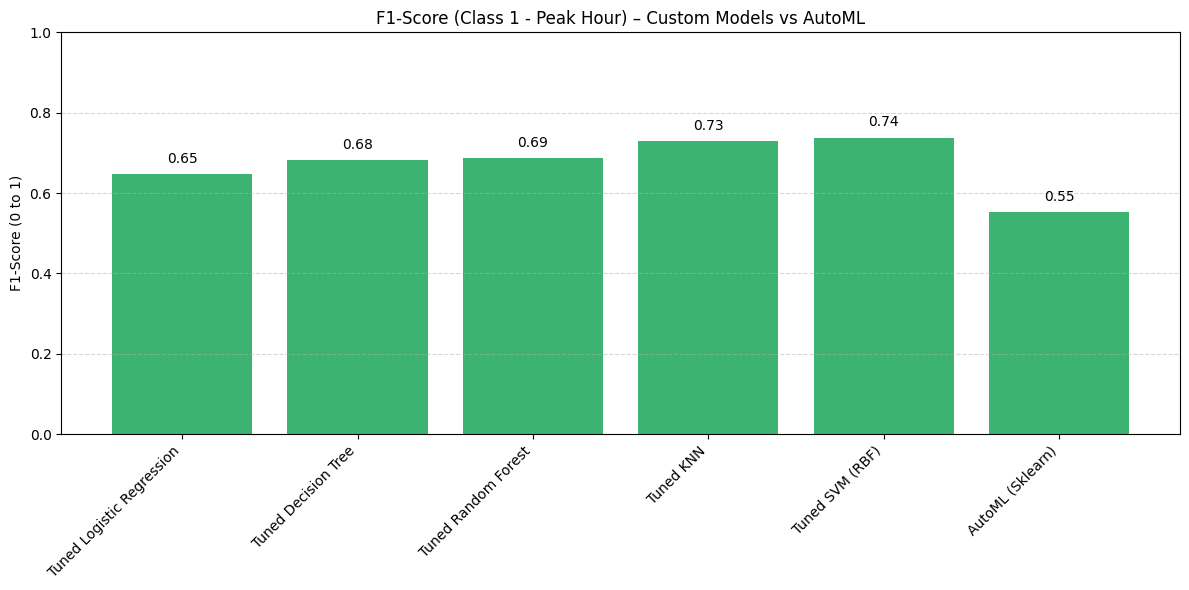

In [ ]:
import matplotlib.pyplot as plt
import re

print("\n--- Generating Bar Chart: F1-Score for Class 1 (Peak Hour) ---")

# Check evaluation_results exists
if 'evaluation_results' not in globals():
    print("Error: 'evaluation_results' is not defined. Please run Cell 9 and AutoML cells first.")
else:
    model_names = []
    f1_scores_class1 = []

    for name, metrics in evaluation_results.items():
        model_names.append(name)

        # Case 1: Direct F1-score
        if 'F1-Score (1)' in metrics:
            f1_scores_class1.append(metrics['F1-Score (1)'])

        # Case 2: Extract from report (AutoML or fallback)
        elif 'Classification Report' in metrics:
            report_lines = metrics['Classification Report'].split('\n')
            # f1 = 0.0
            for line in report_lines:
                if line.strip().startswith('1'):
                    parts = re.split(r'\s+', line.strip())
                    if len(parts) >= 4:
                        try:
                            f1 = float(parts[3])
                        except:
                            f1 = 0.0
                    break
            f1_scores_class1.append(f1)

        else:
            f1_scores_class1.append(0.0)

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(model_names, f1_scores_class1, color='mediumseagreen')
    plt.title("F1-Score (Class 1 - Peak Hour) – Custom Models vs AutoML")
    plt.ylabel("F1-Score (0 to 1)")
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.0)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()